# Package Sizing Problem

Cleaned and restructured notebook for analyzing product dimensions, preparing standardized package dimensions, clustering product types, and simulating package size candidates.

**Notebook flow**
1. Load and inspect data
2. Clean and standardize dimensions
3. Map product dimensions into package-ready `L`, `W`, and `H`
4. Filter eligible records
5. Cluster product types by median dimensions
6. Simulate package sizing options


## Objective and Data Dictionary

**Objective:** Analyze product dimension data and determine suitable box/package sizing groups.

**Key fields**

| Field | Description |
|---|---|
| `ASIN` | Amazon Standard Identification Number; unique product identifier. |
| `PT` | Product Type; product category/group. |
| `height` | Product height. |
| `width` | Product width. |
| `length` | Product length. |
| `depth` | Alternative length-like dimension when length is unavailable. |
| `thickness` | Flat-product thickness. |
| `diameter` | Circular/cylindrical product diameter. |
| `cm` / `inch` columns | Same dimensions in centimeters or inches. |


## 0. Setup

Import libraries and load the dimension dataset.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/drive/MyDrive/UGM/Project_Data_Mining/Dimension Data.xlsx")

In [5]:
# Dimensi data
df.shape

(9617, 14)

In [6]:
# Overview data
df.head()

,ASIN,PT,height cm,width cm,length cm,depth cm,thickness cm,diameter cm,height inch,width inch,length inch,depth inch,thickness inch,diameter inch
0,B00F0B6JHW,AIR_MATTRESS,NaN,152.0,203.0,NaN,46.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B01J1QFAQW,AIR_MATTRESS,NaN,99.0,191.0,NaN,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B01MU4NYV6,AIR_MATTRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.50,NaN
3,B01D19ME46,AIR_MATTRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.95,NaN
4,B07CBTYQ47,AIR_MATTRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.95,NaN


## 1. Initial Data Quality Checks

Create a working copy, inspect missing values, identify duplicates, and validate ASIN uniqueness.


In [7]:
# Separating processed df
processed_df = df.copy()

In [8]:
# Identifikasi missing value
missing_count = processed_df.isna().sum()
missing_count

,0
ASIN,0
PT,0
height cm,6554
width cm,5657
length cm,7625
depth cm,8086
thickness cm,9417
diameter cm,9617
height inch,4175
width inch,2498


In [9]:
# Preferensi cm vs inch
missing_cm = np.sum(missing_count[2:8].values)
missing_inch = np.sum(missing_count[-6:].values)

print(f"Missing value in cm: {missing_cm}")
print(f"Missing value in inch: {missing_inch}")

Missing value in cm: 46956
Missing value in inch: 38527


In [10]:
# Check duplicated record
print(f"Total duplicated: {processed_df.duplicated().sum()} rows")

Total duplicated: 78 rows


In [11]:
# Drop duplicated record
processed_df = processed_df.drop_duplicates()
print(f"Total duplicated: {processed_df.duplicated().sum()} rows")

Total duplicated: 0 rows


In [12]:
# Check ASIN uniqueness
print(f"Total unique ASIN: {processed_df['ASIN'].nunique()} rows")
print(f"Total record ASIN: {processed_df['ASIN'].count()} rows")

Total unique ASIN: 9388 rows
Total record ASIN: 9539 rows


In [13]:
# Check duplicated ASIN code
asin_count = processed_df["ASIN"].value_counts().reset_index()

asin_count.groupby('count')['ASIN'].count().reset_index()

,count,ASIN
0,1,9248
1,2,132
2,3,6
3,4,1
4,5,1


In [14]:
# Check ASIN with 5 duplication
processed_df[processed_df["ASIN"].isin(asin_count.loc[asin_count["count"] == 5]['ASIN'].tolist())]

,ASIN,PT,height cm,width cm,length cm,depth cm,thickness cm,diameter cm,height inch,width inch,length inch,depth inch,thickness inch,diameter inch
8621,B016PZTLRQ,TOWEL_HOLDER,NaN,NaN,NaN,NaN,NaN,NaN,2.13,3.27,26.01,NaN,NaN,NaN
8622,B016PZTLRQ,TOWEL_HOLDER,NaN,NaN,NaN,NaN,NaN,NaN,2.13,3.25,3.25,NaN,NaN,NaN
8623,B016PZTLRQ,TOWEL_HOLDER,NaN,NaN,NaN,NaN,NaN,NaN,2.13,3.27,20.09,NaN,NaN,NaN
8625,B016PZTLRQ,TOWEL_HOLDER,NaN,NaN,NaN,NaN,NaN,NaN,3.37,2.13,3.90,NaN,NaN,NaN
8643,B016PZTLRQ,TOWEL_HOLDER,NaN,NaN,NaN,NaN,NaN,NaN,7.22,2.36,6.37,NaN,NaN,NaN


## 1.1 Unit Standardization

Fill missing centimeter values using available inch values converted to centimeters, then remove inch columns.


In [15]:
# convert inch to cm
dim_pairs = [
    ('height cm', 'height inch'),
    ('width cm', 'width inch'),
    ('length cm', 'length inch'),
    ('depth cm', 'depth inch'),
    ('thickness cm', 'thickness inch'),
    ('diameter cm', 'diameter inch')
]

for cm_col, inch_col in dim_pairs:
    converted_series = processed_df[inch_col] * 2.54
    processed_df[cm_col] = processed_df[cm_col].fillna(converted_series)

print("Missing values after conversion:")
display(processed_df[ [p[0] for p in dim_pairs] ].isna().sum())


Missing values after conversion:


,0
height cm,2639
width cm,522
length cm,5373
depth cm,5697
thickness cm,9167
diameter cm,9539


In [16]:
# Overview of the updated processed_df
display(processed_df.sample(10))


,ASIN,PT,height cm,width cm,length cm,depth cm,thickness cm,diameter cm,height inch,width inch,length inch,depth inch,thickness inch,diameter inch
3448,B08MZY1VZW,DRESSER,55.000,100.000,NaN,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5426,B01N0XQW8T,MATTRESS,NaN,193.040,203.200,NaN,NaN,NaN,NaN,76.00,80.0,NaN,NaN,NaN
481,B07YV3VVFW,BANNER,NaN,110.000,185.000,NaN,NaN,NaN,NaN,43.30,72.8,NaN,NaN,NaN
3642,B09878W15X,DRINKING_CUP,19.812,10.160,NaN,NaN,NaN,NaN,7.80,4.00,NaN,NaN,NaN,NaN
4054,B0797Q555R,HEADBOARD,106.045,200.025,NaN,NaN,NaN,NaN,41.75,78.75,NaN,NaN,NaN,NaN
2509,B06XT18ZYK,CRIB,54.864,79.756,142.748,NaN,NaN,NaN,21.60,31.40,56.2,NaN,NaN,NaN
18,B088ZHP4SR,AIR_MATTRESS,NaN,NaN,NaN,NaN,45.72,NaN,NaN,NaN,NaN,NaN,18.0,NaN
201,B07ZP9G96F,AROMA_DIFFUSER,14.732,11.938,11.938,NaN,NaN,NaN,5.80,4.70,4.7,NaN,NaN,NaN
1350,B07BSKZRM2,BENCH,55.880,137.160,NaN,43.18,NaN,NaN,22.00,54.00,NaN,17.0,NaN,NaN
6743,B089LVFMZN,SAFE,40.000,38.000,NaN,31.00,NaN,NaN,15.80,15.00,NaN,12.2,NaN,NaN


In [17]:
# Identify inch columns
inch_cols = [col for col in processed_df.columns if 'inch' in col]

# Drop the inch columns
processed_df = processed_df.drop(columns=inch_cols)

# Verify the remaining columns
print(f"Dropped columns: {inch_cols}")
print("Remaining columns in processed_df:")
display(processed_df.columns.tolist())
display(processed_df.head())

Dropped columns: ['height inch', 'width inch', 'length inch', 'depth inch', 'thickness inch', 'diameter inch']
Remaining columns in processed_df:


['ASIN',
 'PT',
 'height cm',
 'width cm',
 'length cm',
 'depth cm',
 'thickness cm',
 'diameter cm']

,ASIN,PT,height cm,width cm,length cm,depth cm,thickness cm,diameter cm
0,B00F0B6JHW,AIR_MATTRESS,NaN,152.0,203.0,NaN,46.000,NaN
1,B01J1QFAQW,AIR_MATTRESS,NaN,99.0,191.0,NaN,42.000,NaN
2,B01MU4NYV6,AIR_MATTRESS,NaN,NaN,NaN,NaN,3.810,NaN
3,B01D19ME46,AIR_MATTRESS,NaN,NaN,NaN,NaN,7.493,NaN
4,B07CBTYQ47,AIR_MATTRESS,NaN,NaN,NaN,NaN,7.493,NaN


In [18]:
# Duplikasi tersebut mengindikasikan adanya varian dari produk yang sama atau inkonsistensi pengukuran

## 2. Dimension Preparation

Create standardized dimension columns used in the package sizing workflow.


## 2.1 Core Dimension Selection

Map raw dimension fields into compact working dimensions: `L`, `W`, `H`, `T`, and `D`.


In [19]:
processed_df['L'] = processed_df[['length cm', 'depth cm']].bfill(axis=1).iloc[:, 0] # only use depth if length not available
processed_df['W'] = processed_df['width cm']
processed_df['H'] = processed_df['height cm']
processed_df['T'] = processed_df['thickness cm']
processed_df['D'] = processed_df['diameter cm']

# Drop rows where all core dims are null
processed_df = processed_df.dropna(subset=['L', 'W', 'H', 'T', 'D'], how='all')

In [20]:
processed_df.head()

,ASIN,PT,height cm,width cm,length cm,depth cm,thickness cm,diameter cm,L,W,H,T,D
0,B00F0B6JHW,AIR_MATTRESS,NaN,152.0,203.0,NaN,46.000,NaN,203.0,152.0,NaN,46.000,NaN
1,B01J1QFAQW,AIR_MATTRESS,NaN,99.0,191.0,NaN,42.000,NaN,191.0,99.0,NaN,42.000,NaN
2,B01MU4NYV6,AIR_MATTRESS,NaN,NaN,NaN,NaN,3.810,NaN,NaN,NaN,NaN,3.810,NaN
3,B01D19ME46,AIR_MATTRESS,NaN,NaN,NaN,NaN,7.493,NaN,NaN,NaN,NaN,7.493,NaN
4,B07CBTYQ47,AIR_MATTRESS,NaN,NaN,NaN,NaN,7.493,NaN,NaN,NaN,NaN,7.493,NaN


In [21]:
# processed_df = processed_df.fillna(0)
selected_df = processed_df[['ASIN', 'PT', 'L', 'W', 'H', 'T', 'D']].copy()
selected_df.head()

,ASIN,PT,L,W,H,T,D
0,B00F0B6JHW,AIR_MATTRESS,203.0,152.0,NaN,46.000,NaN
1,B01J1QFAQW,AIR_MATTRESS,191.0,99.0,NaN,42.000,NaN
2,B01MU4NYV6,AIR_MATTRESS,NaN,NaN,NaN,3.810,NaN
3,B01D19ME46,AIR_MATTRESS,NaN,NaN,NaN,7.493,NaN
4,B07CBTYQ47,AIR_MATTRESS,NaN,NaN,NaN,7.493,NaN


In [22]:
pd.set_option('display.max_columns', None)

In [23]:
selected_df.groupby('PT')[['L', 'W', 'H', 'T', 'D']].count()

,L,W,H,T,D
PT,,,,,
AIR_MATTRESS,145,146,0,145,0
AROMA_DIFFUSER,98,98,100,0,0
ARTIFICIAL_TREE,108,108,143,0,0
BANNER,59,58,0,0,0
BARBECUE_GRILL,75,84,75,0,0
...,...,...,...,...,...
TRAY,116,116,100,0,0
UTILITY_CART_WAGON,173,175,174,0,0
VASE,89,89,88,0,0


## 3. Required Dimensions by Product Type

Identify which dimensions are required for each product type, then filter complete records.


In [24]:
# Step 1: Derive required dimensions per PT dynamically
pt_dim_counts = selected_df.groupby('PT')[['L', 'W', 'H', 'T', 'D']].count()

# Required dimensions = those with count > 0 for each PT
pt_required_dims = pt_dim_counts.apply(
    lambda row: [col for col in row.index if row[col] > 0], axis=1
).to_dict()

# pt_required_dims will look like:
# {'AIR_MATTRESS': ['L', 'W', 'T'], 'BOTTLE': ['H', 'D'], ...}

# Step 2: Filter records that fulfill the required dimensions for their PT
def has_required_dims(row):
    required = pt_required_dims.get(row['PT'], [])
    return row[required].notna().all()

filtered_df = selected_df[selected_df.apply(has_required_dims, axis=1)]

In [25]:
filtered_df = filtered_df.reset_index(drop=True)
print(filtered_df.shape)

filtered_df.head()

(8253, 7)


,ASIN,PT,L,W,H,T,D
0,B00F0B6JHW,AIR_MATTRESS,203.00,152.00,NaN,46.000,NaN
1,B01J1QFAQW,AIR_MATTRESS,191.00,99.00,NaN,42.000,NaN
2,B07YP8YPDF,AIR_MATTRESS,127.00,58.42,NaN,6.350,NaN
3,B0038ZCFDY,AIR_MATTRESS,43.00,28.00,NaN,9.000,NaN
4,B07GSKGHFR,AIR_MATTRESS,182.88,55.88,NaN,4.064,NaN


In [26]:
filtered_df.groupby('PT')[['L', 'W', 'H', 'T', 'D']].count()

,L,W,H,T,D
PT,,,,,
AIR_MATTRESS,118,118,0,118,0
AROMA_DIFFUSER,97,97,97,0,0
ARTIFICIAL_TREE,108,108,108,0,0
BANNER,58,58,0,0,0
BARBECUE_GRILL,63,63,63,0,0
...,...,...,...,...,...
TRAY,96,96,96,0,0
UTILITY_CART_WAGON,172,172,172,0,0
VASE,86,86,86,0,0


## 4. Missing Required Dimension Imputation

Fill missing required dimensions using the median value within each product type.


In [27]:
# Step 1: Derive required dimensions per PT dynamically
pt_dim_counts = selected_df.groupby('PT')[['L', 'W', 'H', 'T', 'D']].count()

pt_required_dims = pt_dim_counts.apply(
    lambda row: [col for col in row.index if row[col] > 0], axis=1
).to_dict()

# Step 2: Compute median per PT for each dimension
pt_medians = selected_df.groupby('PT')[['L', 'W', 'H', 'T', 'D']].median()

# Step 3: Fill missing required dimensions using PT median
def fill_required_dims(row):
    required = pt_required_dims.get(row['PT'], [])
    for col in required:
        if pd.isna(row[col]):
            row[col] = pt_medians.loc[row['PT'], col]
    return row

filled_df = selected_df.apply(fill_required_dims, axis=1)

In [28]:
filled_df.head()

,ASIN,PT,L,W,H,T,D
0,B00F0B6JHW,AIR_MATTRESS,203.0,152.0,NaN,46.000,NaN
1,B01J1QFAQW,AIR_MATTRESS,191.0,99.0,NaN,42.000,NaN
2,B01MU4NYV6,AIR_MATTRESS,191.0,99.0,NaN,3.810,NaN
3,B01D19ME46,AIR_MATTRESS,191.0,99.0,NaN,7.493,NaN
4,B07CBTYQ47,AIR_MATTRESS,191.0,99.0,NaN,7.493,NaN


In [29]:
filled_df.groupby('PT')[['L', 'W', 'H', 'T', 'D']].count()

,L,W,H,T,D
PT,,,,,
AIR_MATTRESS,171,171,0,171,0
AROMA_DIFFUSER,101,101,101,0,0
ARTIFICIAL_TREE,143,143,143,0,0
BANNER,59,59,0,0,0
BARBECUE_GRILL,86,86,86,0,0
...,...,...,...,...,...
TRAY,120,120,120,0,0
UTILITY_CART_WAGON,175,175,175,0,0
VASE,91,91,91,0,0


## 4.1 Dimension Requirement Review

Summarize required dimensions by product type and inspect flat-panel thickness assumptions.


In [30]:
pt_required_dims_df = pd.DataFrame([
    {'PT': pt, 'required_dims': tuple(sorted(dims))}
    for pt, dims in pt_required_dims.items()
])

print(pt_required_dims_df.to_string())

                         PT required_dims
0              AIR_MATTRESS     (L, T, W)
1            AROMA_DIFFUSER     (H, L, W)
2           ARTIFICIAL_TREE     (H, L, W)
3                    BANNER        (L, W)
4            BARBECUE_GRILL     (H, L, W)
5                    BASKET     (H, L, W)
6            BEAN_BAG_CHAIR     (H, L, W)
7                       BED     (H, L, W)
8                 BED_FRAME     (H, L, W)
9                     BENCH     (H, L, W)
10                  BLANKET        (L, W)
11                   BOTTLE        (H, W)
12                  CABINET     (H, L, W)
13            CANDLE_HOLDER     (H, L, W)
14                    CHAIR     (H, L, W)
15           CLEANING_BRUSH     (H, L, W)
16           CLOTHES_HANGER        (H, W)
17             CLOTHES_RACK     (H, L, W)
18                     CRIB     (H, L, W)
19                  CURTAIN        (L, W)
20  DECORATIVE_PILLOW_COVER        (L, W)
21                     DESK     (H, L, W)
22            DISHWARE_BOWL       

In [31]:
# Check T and H values for flat panel PTs
flat_panel_pts = pt_required_dims_df[
    pt_required_dims_df['required_dims'] == ('L', 'W')
]['PT'].tolist()

selected_df[selected_df['PT'].isin(flat_panel_pts)][['PT', 'T', 'H']].describe()

,T,H
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


In [32]:
# Check T values from PTs that have T as required dim
has_T_pts = pt_required_dims_df[
    pt_required_dims_df['required_dims'].apply(lambda x: 'T' in x)
]['PT'].tolist()

selected_df[selected_df['PT'].isin(has_T_pts)][['PT', 'T']].describe()

,T
count,372.000000
mean,19.040243
std,14.198865
min,1.193800
25%,7.500000
50%,15.240000
75%,25.400000
max,89.000000


## 5. Geometry Mapping and Volume Calculation

Assign each product type to a geometry group and calculate product volume accordingly.


In [33]:
import numpy as np

# Default thickness from median T of PTs that have T as required dim
DEFAULT_T = selected_df[selected_df['PT'].isin(has_T_pts)]['T'].median()  # 15.24

# Step 1: Assign geometry group per PT based on required dims
def assign_geometry(dims):
    dims_set = set(dims)
    if dims_set == {'L', 'W', 'H'}:
        return 'Box'
    elif dims_set == {'L', 'W', 'T'}:
        return 'Flat Sheet'
    elif dims_set == {'L', 'W'}:
        return 'Flat Panel'
    elif dims_set == {'H', 'W'}:
        return 'Cylinder'
    else:
        return 'Unknown'

pt_required_dims_df['geometry'] = pt_required_dims_df['required_dims'].apply(assign_geometry)

# Step 2: Merge geometry back to filled_df
filled_df = filled_df.merge(
    pt_required_dims_df[['PT', 'geometry']], on='PT', how='left'
)

# Step 3: Fill T for Flat Panel PTs using DEFAULT_T
flat_panel_mask = filled_df['geometry'] == 'Flat Panel'
filled_df.loc[flat_panel_mask, 'T'] = filled_df.loc[flat_panel_mask, 'T'].fillna(DEFAULT_T)

# Step 4: Calculate volume based on geometry
def calculate_volume(row):
    if row['geometry'] == 'Box':
        return row['L'] * row['W'] * row['H']
    elif row['geometry'] == 'Flat Sheet':
        return row['L'] * row['W'] * row['T']
    elif row['geometry'] == 'Flat Panel':
        return row['L'] * row['W'] * row['T']  # T filled with DEFAULT_T
    elif row['geometry'] == 'Cylinder':
        return np.pi * (row['W'] / 2) ** 2 * row['H']
    else:
        return np.nan

filled_df['volume'] = filled_df.apply(calculate_volume, axis=1)

# Step 5: Flag ambiguous cases (has both W and D, or both T and H — not seen in data but future-proof)
def is_ambiguous(dims):
    dims_set = set(dims)
    return int(assign_geometry(dims) == 'Unknown')

pt_required_dims_df['is_ambiguous'] = pt_required_dims_df['required_dims'].apply(is_ambiguous)

filled_df = filled_df.merge(
    pt_required_dims_df[['PT', 'is_ambiguous']], on='PT', how='left'
)

# Summary
print(pt_required_dims_df[['PT', 'required_dims', 'geometry', 'is_ambiguous']].to_string())
print(f"\nVolume calculated for {filled_df['volume'].notna().sum()} records")
print(f"Ambiguous PTs: {pt_required_dims_df[pt_required_dims_df['is_ambiguous'] == 1]['PT'].tolist()}")

                         PT required_dims    geometry  is_ambiguous
0              AIR_MATTRESS     (L, T, W)  Flat Sheet             0
1            AROMA_DIFFUSER     (H, L, W)         Box             0
2           ARTIFICIAL_TREE     (H, L, W)         Box             0
3                    BANNER        (L, W)  Flat Panel             0
4            BARBECUE_GRILL     (H, L, W)         Box             0
5                    BASKET     (H, L, W)         Box             0
6            BEAN_BAG_CHAIR     (H, L, W)         Box             0
7                       BED     (H, L, W)         Box             0
8                 BED_FRAME     (H, L, W)         Box             0
9                     BENCH     (H, L, W)         Box             0
10                  BLANKET        (L, W)  Flat Panel             0
11                   BOTTLE        (H, W)    Cylinder             0
12                  CABINET     (H, L, W)         Box             0
13            CANDLE_HOLDER     (H, L, W)       

In [34]:
filled_df.shape

(9539, 10)

In [35]:
filled_df.sample(10)

,ASIN,PT,L,W,H,T,D,geometry,volume,is_ambiguous
2381,B095S5QVB8,CLOTHES_RACK,32.000,120.000,122.000,NaN,NaN,Box,4.684800e+05,0
1228,B08D9CJ9F3,BENCH,27.940,70.104,45.212,NaN,NaN,Box,8.855700e+04,0
7144,B00BYG7CLO,SINK,40.600,68.600,20.300,NaN,NaN,Box,5.653875e+04,0
9421,B08T1NGGHP,WALL_ART,40.640,30.480,NaN,15.24,NaN,Flat Panel,1.887790e+04,0
410,B07PV5ZZ23,ARTIFICIAL_TREE,81.280,81.280,274.320,NaN,NaN,Box,1.812278e+06,0
1506,B08HRQ198K,BOTTLE,NaN,7.800,26.000,NaN,NaN,Cylinder,1.242374e+03,0
2623,B08HS1LPVH,CURTAIN,45.720,132.080,NaN,15.24,NaN,Flat Panel,9.202975e+04,0
3291,B089Q7YVT6,DRESSER,29.972,55.880,89.408,NaN,NaN,Box,1.497437e+05,0
9304,B084ZRVSQQ,VASE,11.500,11.500,23.200,NaN,NaN,Box,3.068200e+03,0
6328,B0747XRPRJ,ROOM_DIVIDER,NaN,119.380,177.800,NaN,NaN,Cylinder,1.990145e+06,0


## 5.1 Package Dimension Mapping

Convert geometry-specific dimensions into package-ready `mapped_L`, `mapped_W`, and `mapped_H`.


In [36]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── 0. Unit conversion: inches → cm ─────────────────────────────────────────
MIN_L, MIN_W, MIN_H = 15.24, 10.16, 2.54
MAX_L, MAX_W, MAX_H = 91.44, 63.50, 63.50

# ── 1. Map dimensions per geometry to L, W, H ───────────────────────────────
def map_dimensions(row):
    geom = row['geometry']
    if geom == 'Box':
        return row['L'], row['W'], row['H']
    elif geom in ('Flat Sheet', 'Flat Panel'):
        return row['L'], row['W'], row['T']   # T treated as H
    elif geom == 'Cylinder':
        return row['W'], row['W'], row['H']   # W as diameter → L=W=W
    else:
        return np.nan, np.nan, np.nan

filled_df[['mapped_L', 'mapped_W', 'mapped_H']] = filled_df.apply(
    map_dimensions, axis=1, result_type='expand'
)

## 5.2 Eligibility Filtering

Separate products that fit within the target package dimension limits from products outside the limits.


In [37]:
# ── 2. Split into eligible and non-eligible ──────────────────────────────────
def is_eligible(row):
    return (
        row['mapped_L'] >= MIN_L and row['mapped_W'] >= MIN_W and row['mapped_H'] >= MIN_H and
        row['mapped_L'] <= MAX_L and row['mapped_W'] <= MAX_W and row['mapped_H'] <= MAX_H
    )

eligible_mask     = filled_df.apply(is_eligible, axis=1)
eligible_df       = filled_df[eligible_mask].copy()
non_eligible_df   = filled_df[~eligible_mask].copy()

print(f"Eligible:     {len(eligible_df):,} records")
print(f"Non-eligible: {len(non_eligible_df):,} records")

# ── 3. Classify non-eligible with label + violation detail ───────────────────
def classify_non_eligible(row):
    violations = []
    label_flags = {'oversize': False, 'undersize': False}

    # Check undersize
    if row['mapped_L'] < MIN_L:
        violations.append('L below min')
        label_flags['undersize'] = True
    if row['mapped_W'] < MIN_W:
        violations.append('W below min')
        label_flags['undersize'] = True
    if row['mapped_H'] < MIN_H:
        violations.append('H below min')
        label_flags['undersize'] = True

    # Check oversize
    if row['mapped_L'] > MAX_L:
        violations.append('L exceeds max')
        label_flags['oversize'] = True
    if row['mapped_W'] > MAX_W:
        violations.append('W exceeds max')
        label_flags['oversize'] = True
    if row['mapped_H'] > MAX_H:
        violations.append('H exceeds max')
        label_flags['oversize'] = True

    # Assign label
    if label_flags['oversize'] and label_flags['undersize']:
        label = 'both'
    elif label_flags['oversize']:
        label = 'oversize'
    else:
        label = 'undersize'

    return label, ', '.join(violations)

non_eligible_df[['regulation_status', 'violation_detail']] = non_eligible_df.apply(
    classify_non_eligible, axis=1, result_type='expand'
)

print("\nNon-eligible breakdown:")
print(non_eligible_df['regulation_status'].value_counts())



Eligible:     3,368 records
Non-eligible: 6,171 records

Non-eligible breakdown:
regulation_status
oversize     4532
undersize    1531
both          108
Name: count, dtype: int64


## 6. Eligible Data Analysis

Review records that passed the package dimension eligibility rules.


In [38]:
eligible_df.head()

,ASIN,PT,L,W,H,T,D,geometry,volume,is_ambiguous,mapped_L,mapped_W,mapped_H
25,B0038ZCFDY,AIR_MATTRESS,43.0000,28.0000,NaN,22.0,NaN,Flat Sheet,26488.000000,0,43.0000,28.0000,22.0000
28,B0038ZCFDY,AIR_MATTRESS,43.0000,28.0000,NaN,9.0,NaN,Flat Sheet,10836.000000,0,43.0000,28.0000,9.0000
53,B0038ZCFDY,AIR_MATTRESS,43.0000,28.0000,NaN,9.0,NaN,Flat Sheet,10836.000000,0,43.0000,28.0000,9.0000
176,B089D3NFLZ,AROMA_DIFFUSER,16.9926,16.9926,10.0076,NaN,NaN,Box,2889.679036,0,16.9926,16.9926,10.0076
181,B07ZP92QNZ,AROMA_DIFFUSER,15.4940,15.4940,8.3820,NaN,NaN,Box,2012.216750,0,15.4940,15.4940,8.3820


In [39]:
eligible_df.shape

(3368, 13)

## 7. Eligible Product Volume

Calculate mapped volume for eligible products and prepare fields for clustering.


In [40]:
eligible_df['mapped_volume'] = eligible_df['mapped_L'] * eligible_df['mapped_W'] * eligible_df['mapped_H']
eligible_df[['ASIN', 'PT', 'is_ambiguous','mapped_L', 'mapped_W', 'mapped_H', 'mapped_volume']].sample(5)

,ASIN,PT,is_ambiguous,mapped_L,mapped_W,mapped_H,mapped_volume
7792,B01ASXTEY6,STORAGE_BOX,0,60.960,30.48,35.56,66072.642048
7567,B08DYF31PF,STOOL_SEATING,0,39.370,39.37,29.21,45275.409449
7043,B099NHPVL5,SIGNAGE,0,20.000,13.50,15.24,4114.800000
8918,B095T1DNV2,TRASH_CAN,0,27.300,12.70,25.40,8806.434000
4708,B08BFW46LK,LAMP,0,20.828,16.00,39.00,12996.672000


In [41]:
dims = ['mapped_L', 'mapped_W', 'mapped_H']
pt_df = eligible_df.groupby('PT')[dims].median().reset_index()
pt_df

,PT,mapped_L,mapped_W,mapped_H
0,AIR_MATTRESS,43.00000,28.00000,9.0000
1,AROMA_DIFFUSER,16.85018,16.85018,12.0904
2,ARTIFICIAL_TREE,46.86000,46.86000,55.4000
3,BANNER,43.18000,31.75000,15.2400
4,BARBECUE_GRILL,30.98800,45.46600,30.4800
...,...,...,...,...
57,TRAY,33.00000,26.00000,10.6499
58,UTILITY_CART_WAGON,39.00000,44.00000,49.5300
59,VASE,20.16000,20.00000,28.2500
60,WALLPAPER,53.00000,45.00000,15.2400


In [42]:
used_cols = ['ASIN', 'PT', 'geometry', 'is_ambiguous', 'mapped_L', 'mapped_W', 'mapped_H', 'mapped_volume']
final_df = eligible_df[used_cols].set_index('ASIN')
final_df

,PT,geometry,is_ambiguous,mapped_L,mapped_W,mapped_H,mapped_volume
ASIN,,,,,,,
B0038ZCFDY,AIR_MATTRESS,Flat Sheet,0,43.0000,28.0000,22.0000,26488.000000
B0038ZCFDY,AIR_MATTRESS,Flat Sheet,0,43.0000,28.0000,9.0000,10836.000000
B0038ZCFDY,AIR_MATTRESS,Flat Sheet,0,43.0000,28.0000,9.0000,10836.000000
B089D3NFLZ,AROMA_DIFFUSER,Box,0,16.9926,16.9926,10.0076,2889.679036
B07ZP92QNZ,AROMA_DIFFUSER,Box,0,15.4940,15.4940,8.3820,2012.216750
...,...,...,...,...,...,...,...
B08PTV8HLR,WALLPAPER,Flat Panel,0,60.0000,60.0000,15.2400,54864.000000
B08L7JKKWW,WALLPAPER,Flat Panel,0,65.0000,45.0000,15.2400,44577.000000
B08PD9XXXN,WALLPAPER,Flat Panel,0,45.0000,45.0000,15.2400,30861.000000


In [43]:
grouped_final = final_df.groupby('PT')[dims].median().reset_index()
grouped_final

,PT,mapped_L,mapped_W,mapped_H
0,AIR_MATTRESS,43.00000,28.00000,9.0000
1,AROMA_DIFFUSER,16.85018,16.85018,12.0904
2,ARTIFICIAL_TREE,46.86000,46.86000,55.4000
3,BANNER,43.18000,31.75000,15.2400
4,BARBECUE_GRILL,30.98800,45.46600,30.4800
...,...,...,...,...
57,TRAY,33.00000,26.00000,10.6499
58,UTILITY_CART_WAGON,39.00000,44.00000,49.5300
59,VASE,20.16000,20.00000,28.2500
60,WALLPAPER,53.00000,45.00000,15.2400


## 8. Product-Type Median Clustering

Aggregate eligible products by product type and cluster them using median mapped dimensions.


## 8.1 Scaling and Hierarchical Clustering

Scale product-type median dimensions before clustering.


In [44]:
X_raw = grouped_final[["mapped_L", "mapped_W", "mapped_H"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

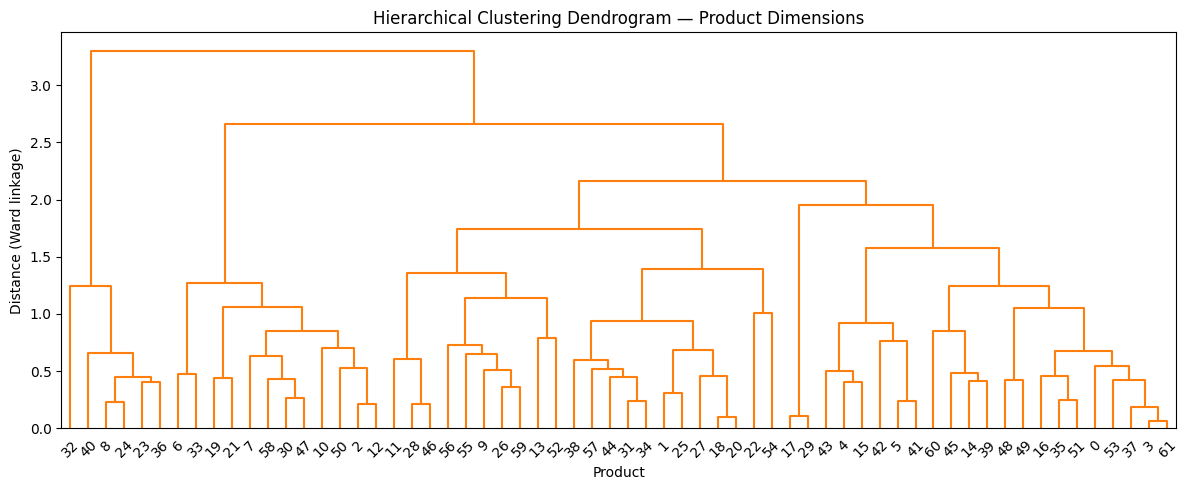

In [45]:
Z_average = linkage(X_scaled, method="average", metric="euclidean")

plt.figure(figsize=(12, 5))
dendrogram(
    Z_average,
    # labels=grouped_final['PT'],
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=3.5  # Draw a horizontal cut line at this height
)
plt.title("Hierarchical Clustering Dendrogram — Product Dimensions")
plt.xlabel("Product")
plt.ylabel("Distance (Ward linkage)")
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 9. Cluster Count Selection

Evaluate cluster counts using silhouette score.


In [47]:
k_range = range(2, 15)  # Try k=2 to k=7
scores = {}

for k in k_range:
    labels = fcluster(Z_average, t=k, criterion="maxclust")
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"  k={k} → silhouette score: {score:.4f}")

best_k = max(scores, key=scores.get)
print(f"\n✅ Best number of clusters: k={best_k} (score={scores[best_k]:.4f})")

  k=2 → silhouette score: 0.3841
  k=3 → silhouette score: 0.3794
  k=4 → silhouette score: 0.3844
  k=5 → silhouette score: 0.3695
  k=6 → silhouette score: 0.3822
  k=7 → silhouette score: 0.4140
  k=8 → silhouette score: 0.4019
  k=9 → silhouette score: 0.4062
  k=10 → silhouette score: 0.3951
  k=11 → silhouette score: 0.3767
  k=12 → silhouette score: 0.3937
  k=13 → silhouette score: 0.3926
  k=14 → silhouette score: 0.3915

✅ Best number of clusters: k=7 (score=0.4140)


In [48]:
best_labels = fcluster(Z_average, t=best_k, criterion="maxclust")

grouped_final["cluster"] = best_labels
print(grouped_final[["PT", "cluster"]].sort_values("cluster").to_string(index=False))

                     PT  cluster
                BLANKET        1
                HAMMOCK        1
            HOME_MIRROR        1
               MATTRESS        1
             PILLOWCASE        1
                    RUG        1
                CABINET        2
        ARTIFICIAL_TREE        2
                DRESSER        2
              FIREPLACE        2
         LAUNDRY_HAMPER        2
          STOOL_SEATING        2
                OTTOMAN        2
                  CHAIR        2
         BEAN_BAG_CHAIR        2
                  BENCH        2
                  TABLE        2
     UTILITY_CART_WAGON        2
           SPACE_HEATER        3
                   LAMP        3
              TRASH_CAN        3
                   VASE        3
             TOY_FIGURE        3
               TOTE_BAG        3
         CLEANING_BRUSH        3
                    JAR        3
                 BOTTLE        3
          CANDLE_HOLDER        3
        JEWELRY_STORAGE        4
         I

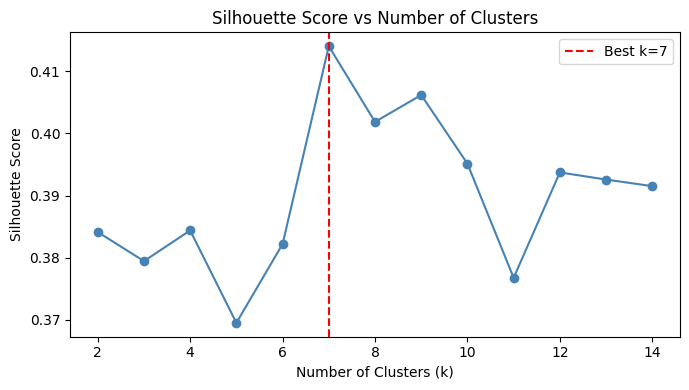

In [49]:
plt.figure(figsize=(7, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Cluster Visualization

Visualize clusters and product-type dimension patterns in 3D.


In [50]:
import plotly.express as px

fig = px.scatter_3d(grouped_final, x=dims[0], y=dims[1], z=dims[2], color='cluster')

fig.show()

In [51]:
fig = px.scatter_3d(grouped_final, x=dims[0], y=dims[1], z=dims[2], color='PT')

fig.show()

In [52]:
fig = px.scatter_3d(eligible_df, x=dims[0], y=dims[1], z=dims[2], color='PT')

fig.show()

In [53]:
print(eligible_df.shape)
print(grouped_final.shape)

(3368, 14)
(62, 5)


In [54]:
cluster_pt_dict = grouped_final.groupby('cluster')['PT'].apply(list).to_dict()
print("Cluster to PT mapping:")
for cluster_id, pt_names in cluster_pt_dict.items():
    print(f"Cluster {cluster_id}: {pt_names}")

Cluster to PT mapping:
Cluster 1: ['BLANKET', 'HAMMOCK', 'HOME_MIRROR', 'MATTRESS', 'PILLOWCASE', 'RUG']
Cluster 2: ['ARTIFICIAL_TREE', 'BEAN_BAG_CHAIR', 'BENCH', 'CABINET', 'CHAIR', 'DRESSER', 'FIREPLACE', 'LAUNDRY_HAMPER', 'OTTOMAN', 'STOOL_SEATING', 'TABLE', 'UTILITY_CART_WAGON']
Cluster 3: ['BOTTLE', 'CANDLE_HOLDER', 'CLEANING_BRUSH', 'JAR', 'LAMP', 'SPACE_HEATER', 'TOTE_BAG', 'TOY_FIGURE', 'TRASH_CAN', 'VASE']
Cluster 4: ['AROMA_DIFFUSER', 'DISHWARE_BOWL', 'DRINKING_CUP', 'FOOD_SLICER', 'INCENSE_HOLDER', 'JEWELRY_STORAGE', 'LIGHT_FIXTURE', 'PICTURE_FRAME', 'PLANTER', 'SIGNAGE', 'TOWEL_HOLDER', 'TRAY']
Cluster 5: ['DESK', 'LAP_DESK']
Cluster 6: ['BARBECUE_GRILL', 'BASKET', 'CLOTHES_RACK', 'SAFE', 'SCULPTURE', 'SHELF']
Cluster 7: ['AIR_MATTRESS', 'BANNER', 'CLOTHES_HANGER', 'DECORATIVE_PILLOW_COVER', 'PILLOW', 'PLACEMAT', 'ROOM_DIVIDER', 'SINK', 'STORAGE_BOX', 'STORAGE_DRAWER', 'TOILET_SEAT', 'TOWEL', 'WALLPAPER', 'WALL_ART']


## 11. Final Cluster Assignment

Map product-type clusters back to product-level records.


In [55]:
pt_to_cluster_map = grouped_final.set_index('PT')['cluster'].to_dict()
final_df['cluster'] = final_df['PT'].map(pt_to_cluster_map)

print("Final DataFrame with cluster information:")
display(final_df.head())

Final DataFrame with cluster information:


,PT,geometry,is_ambiguous,mapped_L,mapped_W,mapped_H,mapped_volume,cluster
ASIN,,,,,,,,
B0038ZCFDY,AIR_MATTRESS,Flat Sheet,0,43.0000,28.0000,22.0000,26488.000000,7
B0038ZCFDY,AIR_MATTRESS,Flat Sheet,0,43.0000,28.0000,9.0000,10836.000000,7
B0038ZCFDY,AIR_MATTRESS,Flat Sheet,0,43.0000,28.0000,9.0000,10836.000000,7
B089D3NFLZ,AROMA_DIFFUSER,Box,0,16.9926,16.9926,10.0076,2889.679036,4
B07ZP92QNZ,AROMA_DIFFUSER,Box,0,15.4940,15.4940,8.3820,2012.216750,4


In [56]:
final_df['mapped_L_log'] = np.log(final_df['mapped_L'])
final_df['mapped_W_log'] = np.log(final_df['mapped_W'])
final_df['mapped_H_log'] = np.log(final_df['mapped_H'])

# fig = px.scatter_3d(final_df, x=dims[0]+"_log", y=dims[1]+"_log", z=dims[2]+"_log", color='cluster')

fig = px.scatter_3d(final_df, x=dims[0], y=dims[1], z=dims[2], color='cluster')

fig.show()

In [57]:
final_df.to_csv('final_df.csv')

In [58]:
final_df.groupby('cluster')[dims].describe()

mapped_L                                                         \
           count       mean        std    min       25%     50%     75%   
cluster                                                                   
1          357.0  68.595494  16.830601  17.00  60.19800  71.000  80.000   
2          481.0  41.972688  11.732794  15.24  35.05200  40.000  47.498   
3          508.0  29.260773  10.664326  15.24  20.00000  26.289  38.000   
4          536.0  29.856187  12.277507  15.24  20.16125  28.321  35.570   
5          108.0  37.191852   4.763788  27.94  33.40100  39.300  40.000   
6          379.0  26.732085   7.725184  15.24  20.06600  26.670  30.667   
7          999.0  45.208429  11.726212  15.24  40.00000  44.958  48.000   

                mapped_W                                                 \
            max    count       mean        std     min     25%      50%   
cluster                                                                   
1        91.440    357.0  46.655928  10.857012  11.500  40.640  50.8000   
2        90.424    481.0  42.678919  10.014109  16.000  37.000  40.0000   
3        76.000    508.0  19.397487   9.594498  10.160  12.700  16.0020   
4        91.000    536.0  23.797143  10.032880  10.160  16.000  22.3520   
5        58.000    108.0  56.235443   6.274860  40.132  53.594  59.7000   
6        57.000    379.0  36.327772  10.757383  10.414  29.050  35.0012   
7        91.440    999.0  36.859465   9.779660  10.500  30.000  36.5000   

                        mapped_H                                           \
            75%     max    count       mean        std      min       25%   
cluster                                                                     
1        51.000  63.500    357.0  15.213221   0.324927  10.1600  15.24000   
2        48.260  63.500    481.0  46.998226  11.259474   9.9822  40.00000   
3        22.860  60.960    508.0  35.133603  13.426166   7.5000  25.45715   
4        29.845  60.960    536.0  15.588884   9.175659   2.7000   8.97500   
5        60.000  62.992    108.0  25.191156   6.728070   6.3500  26.31200   
6        43.090  63.500    379.0  26.197482  14.132209   3.8000  16.63700   
7        44.196  63.500    999.0  19.198777   8.764875   2.6000  15.24000   

                                   
             50%      75%     max  
cluster                            
1        15.2400  15.2400  15.240  
2        50.0000  55.8800  63.500  
3        34.0053  42.0000  63.500  
4        15.2400  17.6445  62.992  
5        26.6000  26.6000  62.865  
6        24.0000  33.0000  63.500  
7        15.2400  20.3200  62.865

## 12. Package Sizing Simulation

Search across percentile-based package sizes and score each option using waste and fit metrics.


In [60]:
from itertools import product
# ── Simulation config ──────────────────────────────────────────────────────────
PERCENTILES   = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 100]
SAMPLE_SIZE   = 100
N_TRIALS      = 30
WASTE_WEIGHT  = 0.5
FIT_WEIGHT    = 0.5
DIMS          = ['mapped_L', 'mapped_W', 'mapped_H']

# All combinations of (pL, pW, pH) — 12^3 = 1728 combinations
COMBINATIONS  = list(product(PERCENTILES, repeat=3))

# ── Scoring function ───────────────────────────────────────────────────────────
def score_combination(sub, pL, pW, pH, n_trials=N_TRIALS, sample_size=SAMPLE_SIZE):
    """
    For a given cluster subset and percentile combo (pL, pW, pH):
    - Randomly sample `sample_size` items `n_trials` times
    - For each trial compute avg waste % and oversize rate
    - Return mean across trials
    """
    cluster_size = len(sub)
    actual_sample = min(sample_size, cluster_size)

    trial_wastes   = []
    trial_oversizes = []

    for _ in range(n_trials):
        sample = sub.sample(n=actual_sample, replace=False)

        # Package dimensions = percentile of sampled items
        pkg_L = np.percentile(sample['mapped_L'], pL)
        pkg_W = np.percentile(sample['mapped_W'], pW)
        pkg_H = np.percentile(sample['mapped_H'], pH)
        pkg_vol = pkg_L * pkg_W * pkg_H

        if pkg_vol == 0:
            continue

        # Oversize: items that don't fit in the package
        oversize_mask = (
            (sample['mapped_L'] > pkg_L) |
            (sample['mapped_W'] > pkg_W) |
            (sample['mapped_H'] > pkg_H)
        )
        oversize_rate = oversize_mask.mean()  # fraction that don't fit

        # Waste: only for items that fit
        fits = sample[~oversize_mask]
        if len(fits) > 0:
            waste_vol  = pkg_vol - fits['mapped_volume']
            avg_waste_pct = (waste_vol / pkg_vol).mean()
        else:
            avg_waste_pct = 1.0  # everything oversized = full waste proxy

        trial_wastes.append(avg_waste_pct)
        trial_oversizes.append(oversize_rate)

    return np.mean(trial_wastes), np.mean(trial_oversizes)

# ── Composite score (lower = better) ──────────────────────────────────────────
def composite_score(avg_waste_pct, oversize_rate,
                    waste_w=WASTE_WEIGHT, fit_w=FIT_WEIGHT):
    """
    Both metrics normalized to [0,1], lower is better.
    waste_pct  : already in [0,1]
    oversize   : already in [0,1]
    """
    return waste_w * avg_waste_pct + fit_w * oversize_rate

# ── Run simulation across all clusters ────────────────────────────────────────
all_results = []

for cluster_id in sorted(final_df['cluster'].unique()):
    sub = final_df[final_df['cluster'] == cluster_id].copy()
    print(f"Simulating cluster {cluster_id} ({len(sub)} items) "
          f"× {len(COMBINATIONS)} combinations × {N_TRIALS} trials ...")

    best_score  = np.inf
    best_combo  = None
    best_metrics = None
    combo_records = []

    for (pL, pW, pH) in COMBINATIONS:
        avg_waste, oversize_rate = score_combination(sub, pL, pW, pH)
        score = composite_score(avg_waste, oversize_rate)

        # Compute actual package dimensions using full cluster (not sample)
        pkg_L = np.percentile(sub['mapped_L'], pL)
        pkg_W = np.percentile(sub['mapped_W'], pW)
        pkg_H = np.percentile(sub['mapped_H'], pH)
        pkg_vol = pkg_L * pkg_W * pkg_H

        combo_records.append({
            'cluster'       : cluster_id,
            'pL'            : pL,
            'pW'            : pW,
            'pH'            : pH,
            'pkg_L'         : round(pkg_L, 2),
            'pkg_W'         : round(pkg_W, 2),
            'pkg_H'         : round(pkg_H, 2),
            'pkg_vol'       : round(pkg_vol, 2),
            'avg_waste_pct' : round(avg_waste * 100, 2),
            'oversize_pct'  : round(oversize_rate * 100, 2),
            'composite_score': round(score, 4),
        })

        if score < best_score:
            best_score   = score
            best_combo   = (pL, pW, pH)
            best_metrics = combo_records[-1]

    all_results.append(best_metrics)

    # Show top 5 for this cluster
    cluster_df = pd.DataFrame(combo_records).sort_values('composite_score')
    print(f"  Top 5 combinations for cluster {cluster_id}:")
    print(cluster_df.head(5)[
        ['pL','pW','pH','pkg_L','pkg_W','pkg_H',
         'avg_waste_pct','oversize_pct','composite_score']
    ].to_string(index=False))
    print()

Simulating cluster 1 (357 items) × 1728 combinations × 30 trials ...
  Top 5 combinations for cluster 1:
 pL  pW  pH  pkg_L  pkg_W  pkg_H  avg_waste_pct  oversize_pct  composite_score
100  99  10  91.44  60.98  15.24          39.07          0.57           0.1982
 95  99  20  91.44  60.98  15.24          39.58          0.53           0.2005
 95 100  60  91.44  63.50  15.24          40.21          0.00           0.2011
 99  99  70  91.44  60.98  15.24          39.69          0.53           0.2011
 99 100  20  91.44  63.50  15.24          40.28          0.00           0.2014

Simulating cluster 2 (481 items) × 1728 combinations × 30 trials ...
  Top 5 combinations for cluster 2:
 pL  pW  pH  pkg_L  pkg_W  pkg_H  avg_waste_pct  oversize_pct  composite_score
 95 100 100   63.5  63.50   63.5          67.24          3.60           0.3542
 95  99 100   63.5  63.50   63.5          67.16          3.70           0.3543
 95  99  99   63.5  63.50   63.5          66.98          4.03           0.3551

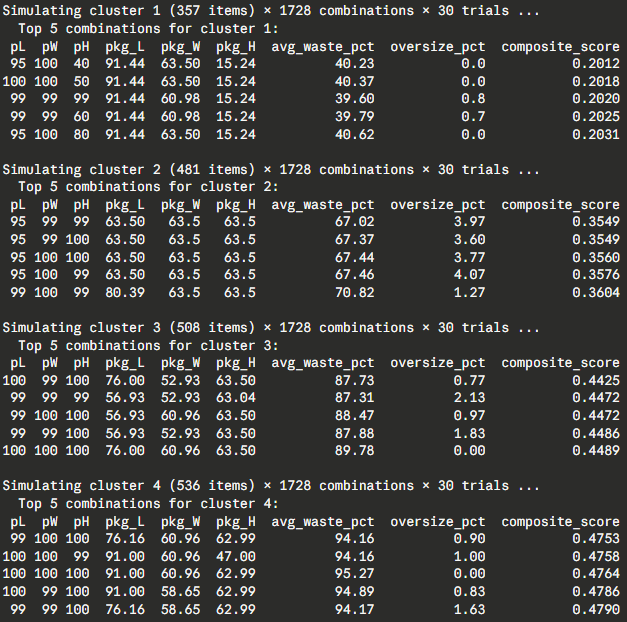


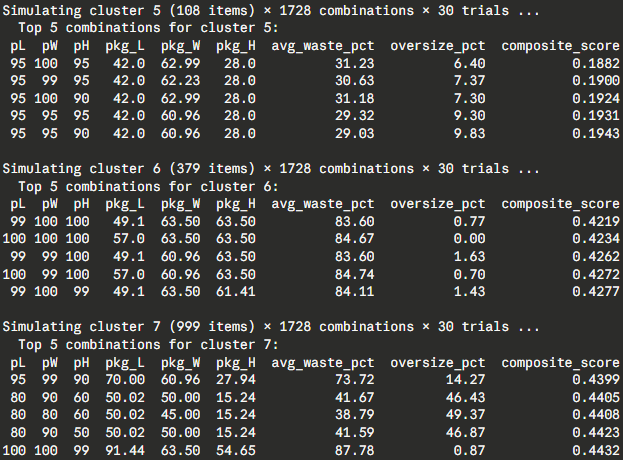